# Bike Sharing Demand Prediction

### VS Code / Jupyter Notebook

**Project goal:** Predict the number of rented bikes using the Seoul Bike Sharing Demand dataset and analyze how weather, time, season, holiday, and functioning-day factors relate to bike demand.

> This notebook is adapted to the project material shown in the VOIS study content. The source material identifies the Seoul Bike Sharing Demand problem and the dataset attributes such as Date, Rented Bike Count, Hour, Temperature, Humidity, Wind speed, Visibility, Dew point temperature, Solar Radiation, Rainfall, Snowfall, Seasons, Holiday, and Functioning Day.


## Cell 1 — Project Understanding

### Problem Statement
Bike-sharing demand changes according to time, weather, season, holidays, and whether the bike-sharing system is functioning. The objective is to build a machine-learning model that predicts the number of bikes rented at a given hour.

### Expected workflow
1. Load the dataset.
2. Inspect and understand the data.
3. Clean and preprocess the data.
4. Perform exploratory data analysis.
5. Visualize important demand patterns.
6. Prepare numerical and categorical features.
7. Train a regression model.
8. Evaluate predictions using regression metrics.
9. Analyze errors and important relationships.
10. Save the trained model for later use.


In [12]:
# Cell 2 — Import required libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("Libraries imported successfully.")


Libraries imported successfully.


## Cell 3 — Locate the dataset

The original project material uses a Google Drive/Colab path. For VS Code, the dataset should be placed inside the project folder or a `data` folder.

Recommended project structure:

```text
Bike_Sharing_Demand_Prediction/
├── Bike_Sharing_Demand_Prediction.ipynb
├── data/
│   └── SeoulBikeData.csv
└── models/
```


In [13]:
# Cell 4 — Find and load Seoul Bike Sharing dataset

# The code checks common VS Code locations so the notebook does not depend on
# Google Colab or Google Drive.

candidate_paths = [
    Path("data/SeoulBikeData.csv"),
    Path("SeoulBikeData.csv"),
    Path("../data/SeoulBikeData.csv"),
    Path("data/SeoulBikeData.xlsx"),
    Path("SeoulBikeData.xlsx"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place SeoulBikeData.csv inside the project folder "
        "or inside a data/ folder, then run this cell again."
    )

if data_path.suffix.lower() == ".csv":
    df = pd.read_csv(data_path, encoding="latin1")
else:
    df = pd.read_excel(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Shape: {df.shape}")


Dataset loaded from: data/SeoulBikeData.csv
Shape: (8760, 14)


In [14]:
# Cell 5 — Initial inspection

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


First 5 rows:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes



Last 5 rows:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes



Dataset shape: (8760, 14)

Column names:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [15]:
# Cell 6 — Dataset information and data types

print("Dataset information:")
df.info()

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-nu

,dtype
Date,str
Rented Bike Count,int64
Hour,int64
Temperature(°C),float64
Humidity(%),int64
Wind speed (m/s),float64
Visibility (10m),int64
Dew point temperature(°C),float64
Solar Radiation (MJ/m2),float64
Rainfall(mm),float64


In [16]:
# Cell 7 — Missing values and duplicate records

missing = df.isnull().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("Missing values:")
display(missing.to_frame("missing_count"))

print(f"Number of duplicate rows: {duplicates}")


Missing values:


,missing_count
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


Number of duplicate rows: 0


In [17]:
# Cell 8 — Clean column names and remove duplicate rows

# Remove accidental leading/trailing spaces from column names.
df.columns = df.columns.str.strip()

before = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print(f"Rows before duplicate removal: {before}")
print(f"Rows after duplicate removal:  {after}")
print(f"Duplicates removed:            {before - after}")


Rows before duplicate removal: 8760
Rows after duplicate removal:  8760
Duplicates removed:            0


In [18]:
# Cell 9 — Convert date and create useful time features

# The dataset's Date column is converted to datetime.
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

    # Calendar features can help the model capture recurring demand patterns.
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek

print("Date conversion and time-feature creation completed.")
display(df.head())


Date conversion and time-feature creation completed.


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Year,Month,Day,DayOfWeek
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4


In [19]:
# Cell 10 — Descriptive statistics

print("Numerical summary:")
display(df.describe(include="all").T)


Numerical summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,8760,NaN,NaN,NaN,2018-06-01 00:00:00,2017-12-01 00:00:00,2018-03-02 00:00:00,2018-06-01 00:00:00,2018-08-31 00:00:00,2018-11-30 00:00:00,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,0.0,191.0,504.5,1065.25,3556.0,644.997468
Hour,8760.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922582
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,-17.8,3.5,13.7,22.5,39.4,11.944825
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,0.0,42.0,57.0,74.0,98.0,20.362413
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,0.0,0.9,1.5,2.3,7.4,1.0363
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,27.0,940.0,1698.0,2000.0,2000.0,608.298712
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,-30.6,-4.7,5.1,14.8,27.2,13.060369
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.0,0.0,0.01,0.93,3.52,0.868746
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,0.0,0.0,0.0,0.0,35.0,1.128193


In [20]:
# Check the actual column names loaded into the DataFrame

print("Dataset shape:", df.shape)
print("\nActual column names:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

Dataset shape: (8760, 18)

Actual column names:
0 'Date'
1 'Rented Bike Count'
2 'Hour'
3 'Temperature(°C)'
4 'Humidity(%)'
5 'Wind speed (m/s)'
6 'Visibility (10m)'
7 'Dew point temperature(°C)'
8 'Solar Radiation (MJ/m2)'
9 'Rainfall(mm)'
10 'Snowfall (cm)'
11 'Seasons'
12 'Holiday'
13 'Functioning Day'
14 'Year'
15 'Month'
16 'Day'
17 'DayOfWeek'


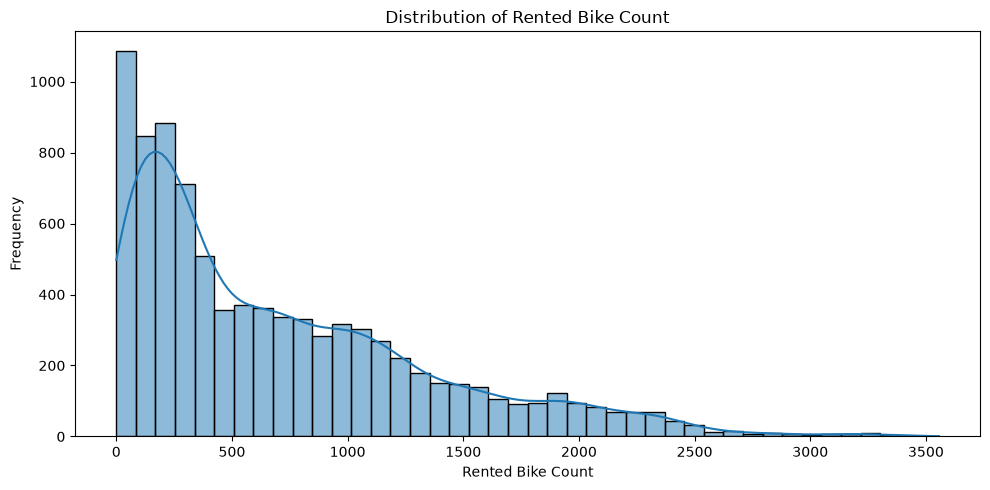

In [21]:
# Cell 11 — Target variable distribution

target = "Rented Bike Count"

if target not in df.columns:
    raise KeyError(f"Target column '{target}' was not found.")

plt.figure(figsize=(10, 5))
sns.histplot(df[target], kde=True)
plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


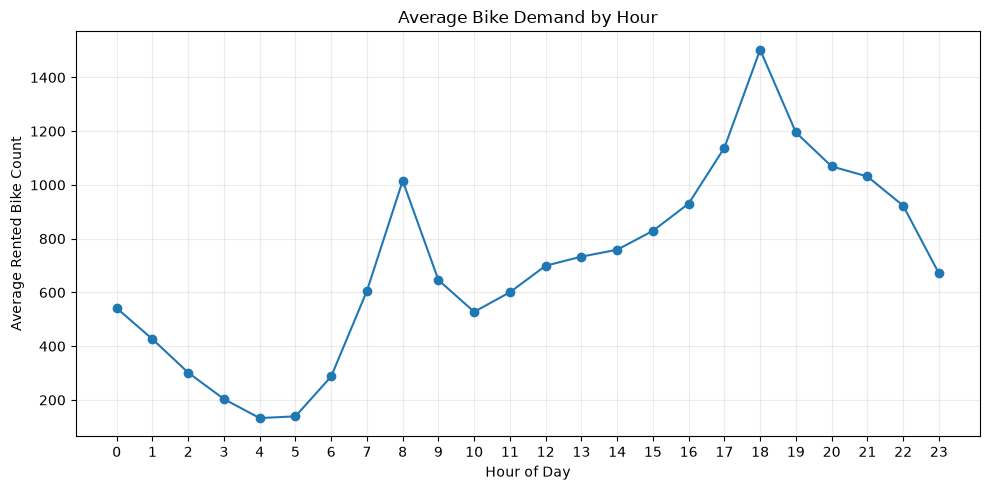

In [22]:
# Cell 12 — Bike demand by hour

if "Hour" in df.columns:
    hourly_demand = df.groupby("Hour")[target].mean()

    plt.figure(figsize=(10, 5))
    hourly_demand.plot(marker="o")
    plt.title("Average Bike Demand by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Rented Bike Count")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


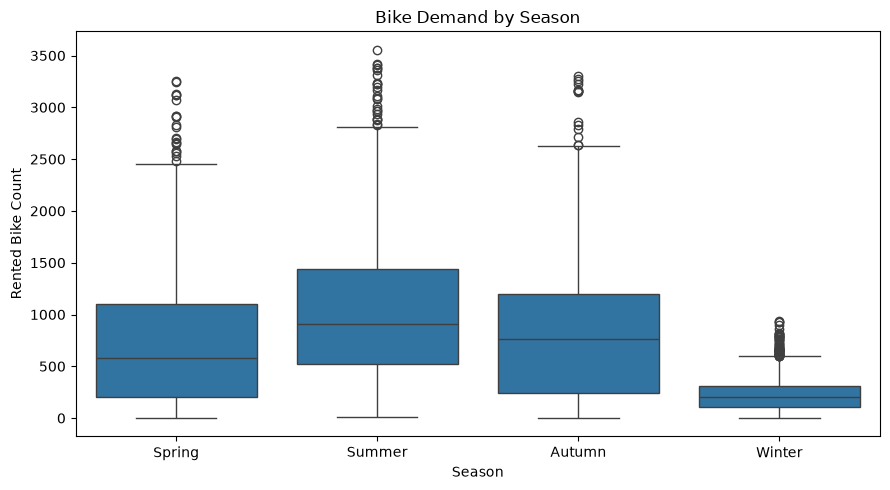

In [23]:
# Cell 13 — Demand by season

if "Seasons" in df.columns:
    season_order = [s for s in ["Spring", "Summer", "Autumn", "Winter"] if s in df["Seasons"].unique()]

    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="Seasons", y=target, order=season_order if season_order else None)
    plt.title("Bike Demand by Season")
    plt.xlabel("Season")
    plt.ylabel("Rented Bike Count")
    plt.tight_layout()
    plt.show()


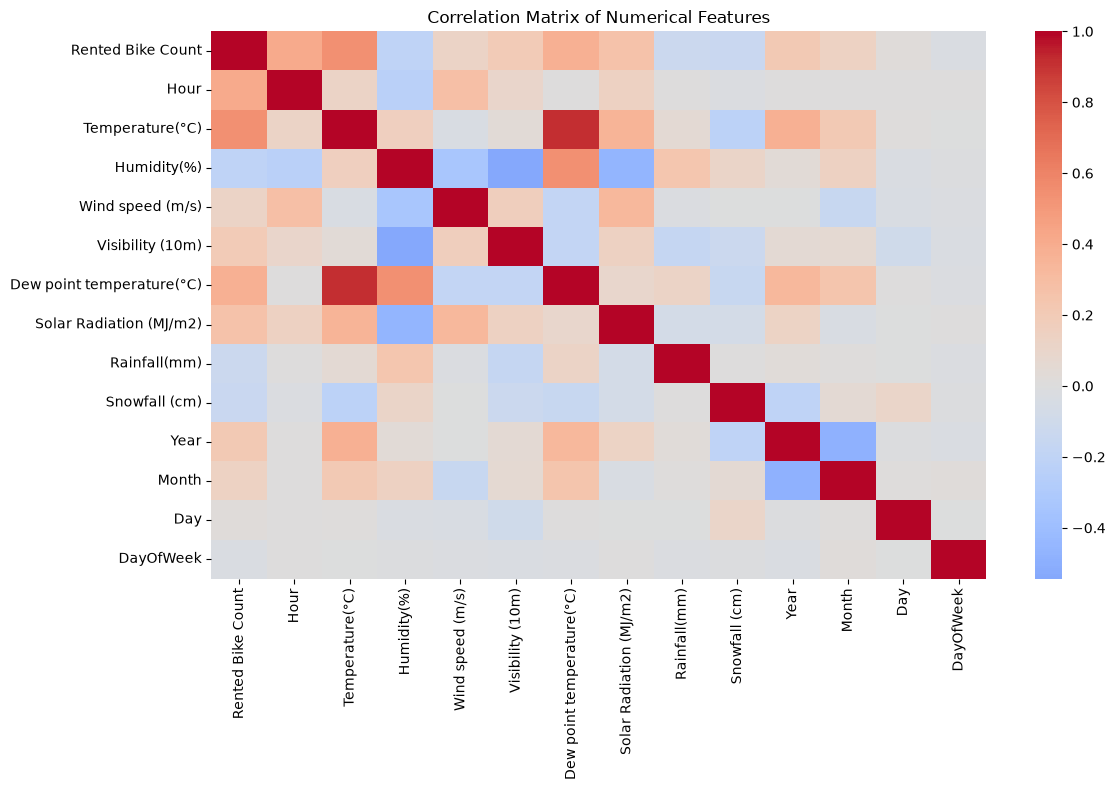

Correlation with target:


,correlation_with_rented_bike_count
Rented Bike Count,1.000000
Temperature(°C),0.538558
Hour,0.410257
Dew point temperature(°C),0.379788
Solar Radiation (MJ/m2),0.261837
Year,0.215162
Visibility (10m),0.199280
Month,0.133514
Wind speed (m/s),0.121108
Day,0.022291


In [24]:
# Cell 14 — Correlation analysis for numerical variables

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

if target in numeric_df.columns:
    print("Correlation with target:")
    display(
        numeric_df.corr()[target]
        .sort_values(ascending=False)
        .to_frame("correlation_with_rented_bike_count")
    )


## Cell 15 — Feature and target preparation

### Target
`Rented Bike Count` is the regression target.

### Candidate numerical features
- Hour
- Temperature
- Humidity
- Wind speed
- Visibility
- Dew point temperature
- Solar Radiation
- Rainfall
- Snowfall
- Year
- Month
- Day
- DayOfWeek

### Candidate categorical features
- Seasons
- Holiday
- Functioning Day

`Date` itself is not directly passed to the regression model because useful calendar information has already been extracted from it.


In [25]:
# Cell 16 — Prepare features and split the data

target = "Rented Bike Count"

numeric_features = [
    "Hour",
    "Temperature",
    "Humidity",
    "Wind speed",
    "Visibility",
    "Dew point temperature",
    "Solar Radiation",
    "Rainfall",
    "Snowfall",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
]

categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day",
]

# Keep only columns that actually exist in the dataset.
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

feature_columns = numeric_features + categorical_features

if not feature_columns:
    raise ValueError("No model features were found. Check the dataset column names.")

model_df = df[feature_columns + [target]].copy()

# Remove rows with missing values in required model columns.
model_df = model_df.dropna().copy()

X = model_df[feature_columns]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Features used:", feature_columns)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Features used: ['Hour', 'Year', 'Month', 'Day', 'DayOfWeek', 'Seasons', 'Holiday', 'Functioning Day']
Training samples: 7008
Testing samples: 1752


In [26]:
# Cell 17 — Build preprocessing pipeline and Linear Regression model

# Numerical columns are scaled.
# Categorical columns are one-hot encoded.
# Linear Regression is the primary regression model shown in the project material.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    remainder="drop"
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [27]:
# Cell 18 — Generate predictions and evaluate the model

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-" * 30)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


Model Evaluation Results
------------------------------
MAE  : 369.2852
RMSE : 495.2026
R²   : 0.4114


,Actual,Predicted
0,1728,853.032921
1,822,1041.738505
2,658,1123.047853
3,2716,1205.495600
4,1083,583.477987
5,636,590.357572
6,1537,1368.030101
7,712,1288.713269
8,425,801.772262
9,594,568.077136


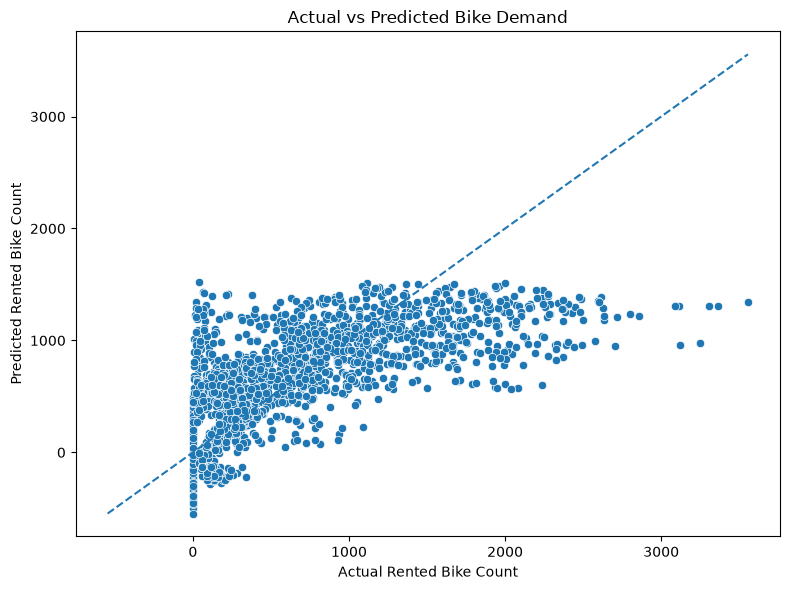

In [28]:
# Cell 19 — Actual vs predicted values

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(results.head(10))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=results, x="Actual", y="Predicted")
plt.title("Actual vs Predicted Bike Demand")
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")

min_value = min(results["Actual"].min(), results["Predicted"].min())
max_value = max(results["Actual"].max(), results["Predicted"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.tight_layout()
plt.show()


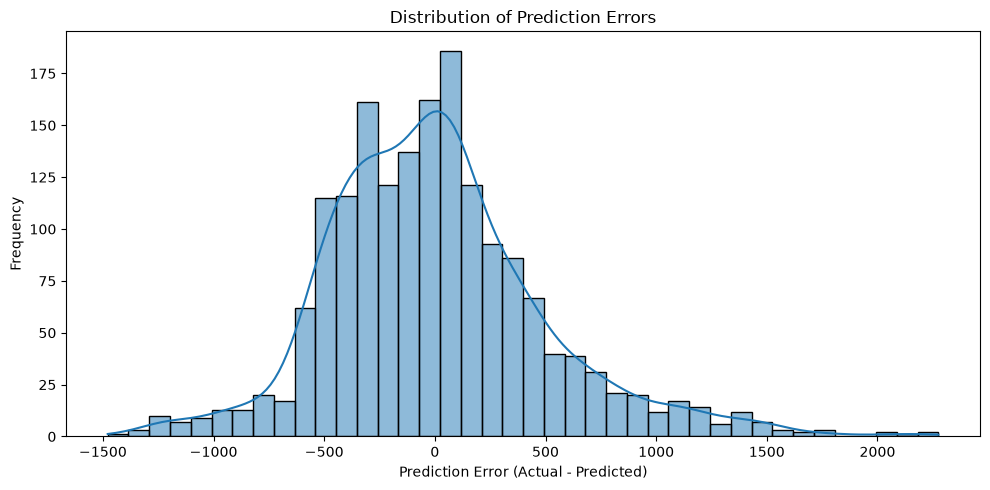

Mean absolute error: 369.28518307241825
Largest absolute error: 2275.568060096018


In [29]:
# Cell 20 — Prediction error analysis

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute Error"] = results["Error"].abs()

plt.figure(figsize=(10, 5))
sns.histplot(results["Error"], kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Mean absolute error:", results["Absolute Error"].mean())
print("Largest absolute error:", results["Absolute Error"].max())


In [30]:
# Cell 21 — Analyze model coefficients

# Linear Regression coefficients can be inspected after preprocessing.
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute Coefficient"] = coefficient_df["Coefficient"].abs()
coefficient_df = coefficient_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

display(coefficient_df.head(15))


,Feature,Coefficient,Absolute Coefficient
0,num__Hour,891.119308,891.119308
8,cat__Seasons_Winter,-655.648149,655.648149
11,cat__Functioning Day_No,-444.902791,444.902791
12,cat__Functioning Day_Yes,444.902791,444.902791
1,num__Year,-403.140134,403.140134
2,num__Month,-373.537592,373.537592
7,cat__Seasons_Summer,350.500188,350.500188
5,cat__Seasons_Autumn,346.093275,346.093275
4,num__DayOfWeek,-74.960261,74.960261
6,cat__Seasons_Spring,-40.945314,40.945314


In [31]:
# Cell 22 — Save the trained model

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "bike_sharing_demand_linear_regression.pkl"
joblib.dump(model, model_path)

print(f"Model saved to: {model_path}")


Model saved to: models/bike_sharing_demand_linear_regression.pkl


In [32]:
# Cell 23 — Reload the saved model and verify it

loaded_model = joblib.load(model_path)
verification_predictions = loaded_model.predict(X_test)

verification_mae = mean_absolute_error(y_test, verification_predictions)

print(f"Reloaded model verification MAE: {verification_mae:.4f}")
print("Model reload verification completed successfully.")


Reloaded model verification MAE: 369.2852
Model reload verification completed successfully.


## Cell 24 — Final Project Summary

After executing all cells, record the **actual outputs** from your run:

- Dataset shape
- Number of duplicate rows removed
- Main demand patterns from EDA
- MAE
- RMSE
- R²
- Important features/relationships
- Saved model filename

### PPT evidence to capture
Use screenshots from the executed notebook for:
1. Dataset overview
2. Problem/analysis section
3. Important EDA chart(s)
4. Correlation analysis
5. Model evaluation metrics
6. Actual-vs-predicted plot
7. Error analysis
8. Saved model/result

**Do not write invented metrics in the PPT. Use the values produced by your actual VS Code execution.**
